# Agribusiness Data Cleaning — Agmarknet Mandi Price Dataset

This notebook walks through the full data acquisition-to-cleaning pipeline step by step.
Each code cell is preceded by a markdown cell explaining **what** it does and **why** that
approach was chosen over alternatives — so you can explain every line if your mentor asks.

**Dataset:** Agmarknet daily mandi price snapshot (State / District / Market / Commodity /
Variety / Grade / Arrival Date / Min, Max, Modal Price).

Replace the `SRC` path below with the path to your own CSV if it's different.

## Step 0 — Import libraries

We need `pandas` for data manipulation, `numpy` for numerical operations (like the IQR
calculation), and `matplotlib` for the charts we'll generate at the end for the report.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## Step 1 — Load the raw data and do a first inspection

Before touching anything, look at the raw structure: how many rows/columns, what data
types pandas inferred, and get a first feel for the data. This is also where we fix the
awkward auto-encoded column names that some CSV exports produce (`Min_x0020_Price` is
just `Min Price` with the space escaped as `x0020`).

In [2]:
SRC = "agmarknet_raw.csv"

df = pd.read_csv(SRC)

# Clean up the encoded column headers
df = df.rename(columns={
    "Min_x0020_Price": "Min_Price",
    "Max_x0020_Price": "Max_Price",
    "Modal_x0020_Price": "Modal_Price",
})

print("Shape:", df.shape)
df.head()

Shape: (9603, 10)


,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min_Price,Max_Price,Modal_Price
0,Tripura,Dhalai,Kulai APMC,Bhindi(Ladies Finger),Bhindi,Grade B,23/08/2026,5500.0,6000.0,5800.0
1,Tripura,Dhalai,Kulai APMC,Sponge gourd,Other,Grade B,23/08/2026,7500.0,8000.0,7700.0
2,Tripura,Dhalai,Kulai APMC,Bitter gourd,Bitter Gourd,Grade B,23/08/2026,9600.0,10000.0,9800.0
3,Keralam,Kozhikode(Calicut),Mukkom Market,Banana,Other,Large,23/08/2026,6300.0,6500.0,6400.0
4,Keralam,Kozhikode(Calicut),Mukkom Market,Banana - Green,Banana - Green,FAQ,23/08/2026,6300.0,6500.0,6400.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9603 entries, 0 to 9602
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   State         9603 non-null   object 
 1   District      9603 non-null   object 
 2   Market        9603 non-null   object 
 3   Commodity     9603 non-null   object 
 4   Variety       9603 non-null   object 
 5   Grade         9603 non-null   object 
 6   Arrival_Date  9603 non-null   object 
 7   Min_Price     9603 non-null   float64
 8   Max_Price     9603 non-null   float64
 9   Modal_Price   9603 non-null   float64
dtypes: float64(3), object(7)
memory usage: 750.4+ KB


## Step 2 — Check for missing values and exact duplicates

This is the standard first quality check. `isnull().sum()` tells you how many missing
values exist per column, and `duplicated().sum()` tells you how many rows are byte-for-byte
identical to another row (true duplicates, which should almost always be dropped).

In [4]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nExact duplicate rows:", df.duplicated().sum())

Missing values per column:
State           0
District        0
Market          0
Commodity       0
Variety         0
Grade           0
Arrival_Date    0
Min_Price       0
Max_Price       0
Modal_Price     0
dtype: int64

Exact duplicate rows: 0


## Step 3 — Check categorical consistency

Numeric checks won't catch spelling inconsistencies in text columns — you have to look at
the actual unique values. Here we print the sorted unique values of `State` and scan for
anything that looks like the same place spelled two different ways (e.g. "Keralam" vs
"Kerala"). This step is inherently manual — there's no formula that finds these for you,
you have to read the list.

In [5]:
print("Unique States:")
print(sorted(df['State'].unique()))

Unique States:
['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chattisgarh', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Karnataka', 'Keralam', 'Madhya Pradesh', 'Maharashtra', 'NCT of Delhi', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [6]:
print("Unique Grades:")
print(sorted(df['Grade'].unique()))
print("\nNumber of unique Commodity strings:", df['Commodity'].nunique())

Unique Grades:
['FAQ', 'Grade A', 'Grade B', 'Grade C', 'Grade Range-1', 'Grade Range-2', 'Large', 'Local', 'Medium', 'Non-FAQ', 'Small', 'TD 3 (FAQ)']

Number of unique Commodity strings: 176


## Step 4 — Fix inconsistent categorical labels

Once you've spotted inconsistent spellings in Step 3, fix them with an explicit mapping
dictionary. Using an explicit dictionary (rather than something automatic like fuzzy
matching) is safer here — automatic matching can accidentally merge two genuinely
different names. We also strip stray whitespace from every text column, which is a cheap,
zero-risk cleanup that prevents `"Kerala"` and `"Kerala "` from being treated as different
groups later.

In [7]:
STATE_MAP = {
    "Keralam": "Kerala",
    "Chattisgarh": "Chhattisgarh",
    "NCT of Delhi": "Delhi",
}

text_cols = ["State", "District", "Market", "Commodity", "Variety", "Grade"]
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

df["State"] = df["State"].replace(STATE_MAP)

print("States after standardization:", sorted(df['State'].unique()))

States after standardization: ['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Delhi', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


## Step 5 — Normalize the Grade field into a controlled taxonomy

Looking at the unique Grade values in Step 3, you'll notice they actually mix three
different concepts: **quality** grades (Grade A, FAQ, Non-FAQ...), **size** grades
(Small, Medium, Large), and **market-type** indicators (Local). Flattening all of these
into one category loses information. Instead, we map each raw Grade value to a new
`Grade_Category` column — keeping the original `Grade` column untouched so no information
is lost, just organized.

In [8]:
GRADE_TAXONOMY = {
    "Grade A": "Quality Grade",
    "Grade B": "Quality Grade",
    "Grade C": "Quality Grade",
    "Grade Range-1": "Quality Grade",
    "Grade Range-2": "Quality Grade",
    "FAQ": "Quality Grade",
    "Non-FAQ": "Quality Grade",
    "TD 3 (FAQ)": "Quality Grade",
    "Small": "Size Grade",
    "Medium": "Size Grade",
    "Large": "Size Grade",
    "Local": "Market Type",
}

df["Grade_Category"] = df["Grade"].map(GRADE_TAXONOMY).fillna("Unclassified")
df["Grade_Category"].value_counts()

Grade_Category
Market Type      7325
Quality Grade    2030
Size Grade        248
Name: count, dtype: int64

## Step 6 — Check price logic validity

Each row has a Min, Max, and Modal price. Logically: `Min_Price <= Modal_Price <= Max_Price`
should always hold, and no price should be zero or negative. We check both conditions
explicitly rather than assuming they hold — this is exactly the kind of silent error that
can wreck downstream statistics if it slips through unnoticed.

In [9]:
invalid_order = (
    (df["Min_Price"] > df["Max_Price"]) |
    (df["Modal_Price"] < df["Min_Price"]) |
    (df["Modal_Price"] > df["Max_Price"])
)
non_positive = (df[["Min_Price", "Max_Price", "Modal_Price"]] <= 0).any(axis=1)

print("Rows with invalid price order:", invalid_order.sum())
print("Rows with non-positive prices:", non_positive.sum())

# If any exist, they'd genuinely be broken records — drop them
df = df[~invalid_order & ~non_positive].copy()
print("Remaining rows:", len(df))

Rows with invalid price order: 0
Rows with non-positive prices: 0
Remaining rows: 9603


## Step 7 — Detect price outliers, per commodity (not globally)

This is the most important modeling decision in the whole pipeline, so it's worth
understanding *why* we do it this way.

A single global outlier threshold (e.g. "flag anything above ₹20,000") would fail badly
here, because different commodities have completely different natural price scales —
garlic and spices trade far higher per quintal than potatoes or leafy greens. A global
threshold would flag *all* expensive commodities as outliers and miss real errors within
cheap commodities.

The fix: compute outlier bounds **separately for each commodity** using the IQR
(interquartile range) method — flag values more than 1.5×IQR below the 25th percentile or
above the 75th percentile, *within that commodity's own price distribution*. IQR is
preferred over a z-score/standard-deviation approach because commodity prices are usually
right-skewed (a few very expensive trades), and IQR is more robust to that skew than
methods that assume a roughly symmetric (normal) distribution.

In [10]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

df["_lower"], df["_upper"] = np.nan, np.nan

for commodity, group in df.groupby("Commodity"):
    if len(group) >= 5:  # need a handful of samples for IQR to be meaningful
        lower, upper = iqr_bounds(group["Modal_Price"])
    else:
        lower, upper = -np.inf, np.inf  # too few samples to judge — don't flag
    df.loc[group.index, "_lower"] = lower
    df.loc[group.index, "_upper"] = upper

df["Price_Outlier_Flag"] = ~df["Modal_Price"].between(df["_lower"], df["_upper"])

n_outliers = df["Price_Outlier_Flag"].sum()
print(f"Outliers flagged: {n_outliers} ({100*n_outliers/len(df):.2f}% of records)")

Outliers flagged: 344 (3.58% of records)


## Step 8 — Flag suspicious Min–Max spread and likely unit-entry errors

Two more targeted checks, aimed at a specific real-world error pattern: a price
mistakenly entered per-kilogram instead of per-quintal (100 kg), which makes the value
look ~100x too small.

- **Spread ratio**: `Max_Price / Min_Price`. A ratio above 10x in a single market on a
  single day is unusual and worth flagging for review.
- **Suspected unit error**: a modal price under 2% of that commodity's typical (median)
  price — but only for commodities whose median price is meaningfully large (>₹100), so we
  don't misclassify commodities that are legitimately cheap.

Both are **flags**, not automatic corrections. We don't multiply the suspected values by
100 automatically, because a wrong automatic "fix" is worse than a visible flag — the flag
preserves the original data and lets a human decide.

In [11]:
df["Spread_Ratio"] = df["Max_Price"] / df["Min_Price"].replace(0, np.nan)
SPREAD_THRESHOLD = 10.0
df["Spread_Anomaly_Flag"] = df["Spread_Ratio"] > SPREAD_THRESHOLD

median_by_commodity = df.groupby("Commodity")["Modal_Price"].transform("median")
df["Suspected_Unit_Error"] = (df["Modal_Price"] < 0.02 * median_by_commodity) & (median_by_commodity > 100)

print("Spread anomalies flagged:", df["Spread_Anomaly_Flag"].sum())
print("Suspected unit errors flagged:", df["Suspected_Unit_Error"].sum())

# quick look at what got flagged
df[df["Suspected_Unit_Error"]][["State", "Market", "Commodity", "Modal_Price"]].head(10)

Spread anomalies flagged: 8
Suspected unit errors flagged: 22


,State,Market,Commodity,Modal_Price
782,Maharashtra,Pune(Moshi) APMC,Spinach,8.00
784,Maharashtra,Pune(Moshi) APMC,Coriander(Leaves),6.00
1101,Maharashtra,Pune(Pimpri) APMC,Coriander(Leaves),8.00
2605,Maharashtra,Pune(Moshi) APMC,Onion Green,15.00
2606,Maharashtra,Pune(Moshi) APMC,Mint(Pudina),8.00
3611,Maharashtra,Rahata APMC,Spinach,6.00
3684,Punjab,Patti APMC,Bhindi(Ladies Finger),0.40
3685,Punjab,Patti APMC,Bitter gourd,0.38
3686,Punjab,Patti APMC,Banana,3.50
3687,Punjab,Patti APMC,Raddish,45.50


## Step 9 — Assess duplicates beyond exact row matches

We already checked exact duplicate rows in Step 2. Here we check a subtler case: rows that
share the same State/District/Market/Commodity/Variety but differ in `Grade`. These are
**not** data-entry duplicates — a market can legitimately trade the same crop at multiple
quality grades on the same day. We identify them so we can explicitly justify keeping them,
rather than accidentally dropping real data.

In [12]:
dup_mask = df.duplicated(
    subset=["State", "District", "Market", "Commodity", "Variety"], keep=False
)
print("Rows sharing Market/Commodity/Variety but differing in Grade:", dup_mask.sum())

# These are kept deliberately — no action needed, just documented
df[dup_mask].sort_values(["Market", "Commodity"]).head(10)

Rows sharing Market/Commodity/Variety but differing in Grade: 26


,State,District,Market,Commodity,Variety,Grade,Arrival_Date,Min_Price,Max_Price,Modal_Price,Grade_Category,_lower,_upper,Price_Outlier_Flag,Spread_Ratio,Spread_Anomaly_Flag,Suspected_Unit_Error
2712,Jammu and Kashmir,Shopian,APMC/MAC Shopian,Apple,Hdp Gala Group,Grade B,23/08/2026,8000.0,12000.0,10000.0,Quality Grade,-13250.0000,45750.0000,False,1.500000,False,False
2713,Jammu and Kashmir,Shopian,APMC/MAC Shopian,Apple,Hdp Gala Group,Grade A,23/08/2026,14000.0,16000.0,15000.0,Quality Grade,-13250.0000,45750.0000,False,1.142857,False,False
4644,Jammu and Kashmir,Shopian,APMC/MAC Shopian,Pear(Marasebu),Babbugosha,Grade B,23/08/2026,3750.0,5000.0,4375.0,Quality Grade,1750.0000,13750.0000,False,1.333333,False,False
8543,Jammu and Kashmir,Shopian,APMC/MAC Shopian,Pear(Marasebu),Babbugosha,Grade A,23/08/2026,5625.0,6875.0,6250.0,Quality Grade,1750.0000,13750.0000,False,1.222222,False,False
8410,Maharashtra,Gadchiroli,Armori(Desaiganj) APMC,Paddy(Common),Other,Non-FAQ,23/08/2026,2000.0,2300.0,2101.0,Quality Grade,2030.0000,2934.0000,False,1.150000,False,False
8411,Maharashtra,Gadchiroli,Armori(Desaiganj) APMC,Paddy(Common),Other,FAQ,23/08/2026,2600.0,3750.0,3178.0,Quality Grade,2030.0000,2934.0000,True,1.442308,False,False
4947,Madhya Pradesh,Khargone,Bedia APMC,Chili Red,Red,Non-FAQ,23/08/2026,7000.0,7900.0,7500.0,Quality Grade,-4000.0000,37600.0000,False,1.128571,False,False
6853,Madhya Pradesh,Khargone,Bedia APMC,Chili Red,Red,FAQ,23/08/2026,8000.0,8000.0,8000.0,Quality Grade,-4000.0000,37600.0000,False,1.000000,False,False
770,Maharashtra,Pune,Dound APMC,Wheat,Maharashtra 2189,FAQ,23/08/2026,2600.0,2650.0,2600.0,Quality Grade,2231.2225,2747.9625,False,1.019231,False,False
8425,Maharashtra,Pune,Dound APMC,Wheat,Maharashtra 2189,Non-FAQ,23/08/2026,2000.0,2000.0,2000.0,Quality Grade,2231.2225,2747.9625,True,1.000000,False,False


## Step 10 — Add derived fields for analysis

Two new columns that make downstream analysis easier:

- **`Price_Range`**: `Max_Price - Min_Price`, a simple measure of intra-day price
  dispersion at each market.
- **`Modal_Price_Normalized`**: min-max scaling of modal price, computed **within each
  commodity group** (not globally). Normalizing within-commodity matters: a global min-max
  scale would compress cheap staples like potato into a near-zero band once compared
  against high-value commodities like garlic, destroying any meaningful variation among the
  staples themselves.

In [13]:
df["Price_Range"] = df["Max_Price"] - df["Min_Price"]

def minmax_norm(s):
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo) if hi > lo else 0.0

df["Modal_Price_Normalized"] = df.groupby("Commodity")["Modal_Price"].transform(minmax_norm)

df[["Commodity", "Modal_Price", "Modal_Price_Normalized"]].head()

,Commodity,Modal_Price,Modal_Price_Normalized
0,Bhindi(Ladies Finger),5800.0,0.773321
1,Sponge gourd,7700.0,1.000000
2,Bitter gourd,9800.0,0.979999
3,Banana,6400.0,0.639874
4,Banana - Green,6400.0,0.590909


## Step 11 — Generate summary statistics (for your report's Data Quality / Impact sections)

Pull together the before/after numbers you'll quote in your DOC — record counts, flagged
counts, and price distribution stats with and without outliers. These are the exact figures
that should go into your "Data Quality Assessment" and "Impact of Cleaning" sections.

In [14]:
summary = {
    "final_row_count": len(df),
    "states_count": df["State"].nunique(),
    "districts_count": df["District"].nunique(),
    "markets_count": df["Market"].nunique(),
    "commodities_count": df["Commodity"].nunique(),
    "price_outliers_flagged": int(df["Price_Outlier_Flag"].sum()),
    "spread_anomalies_flagged": int(df["Spread_Anomaly_Flag"].sum()),
    "suspected_unit_errors_flagged": int(df["Suspected_Unit_Error"].sum()),
}
for k, v in summary.items():
    print(f"{k}: {v}")

print("\nModal price stats — ALL records:")
print(df["Modal_Price"].describe())

print("\nModal price stats — EXCLUDING flagged outliers:")
print(df[~df["Price_Outlier_Flag"]]["Modal_Price"].describe())

final_row_count: 9603
states_count: 23
districts_count: 264
markets_count: 710
commodities_count: 176
price_outliers_flagged: 344
spread_anomalies_flagged: 8
suspected_unit_errors_flagged: 22

Modal price stats — ALL records:
count      9603.000000
mean       5428.423102
std        6048.712904
min           0.300000
25%        2750.000000
50%        4100.000000
75%        6000.000000
max      133088.680000
Name: Modal_Price, dtype: float64

Modal price stats — EXCLUDING flagged outliers:
count      9259.000000
mean       5398.026800
std        5926.197625
min           0.300000
25%        2750.000000
50%        4000.000000
75%        6000.000000
max      133088.680000
Name: Modal_Price, dtype: float64


## Step 12 — Save the cleaned dataset

Drop the helper columns we used internally (`_lower`, `_upper`) and save the final cleaned
CSV — this is your actual deliverable dataset, ready for analysis or to submit alongside
your report.

In [15]:
clean_df = df.drop(columns=["_lower", "_upper"])
clean_df.to_csv("agmarknet_cleaned.csv", index=False)
print("Saved:", clean_df.shape)

Saved: (9603, 17)


## Step 13 — Visualize the results

Three charts that support your report's Impact section:

1. Distribution of modal prices (log scale) — shows why per-commodity outlier fencing was
   necessary in the first place (the heavy right tail spans multiple orders of magnitude).
2. Record volume by state — shows sampling concentration, a caveat worth noting for any
   state-comparison analysis.
3. Count of records flagged under each quality-issue category — a quick visual summary of
   Step 7 and Step 8's output.

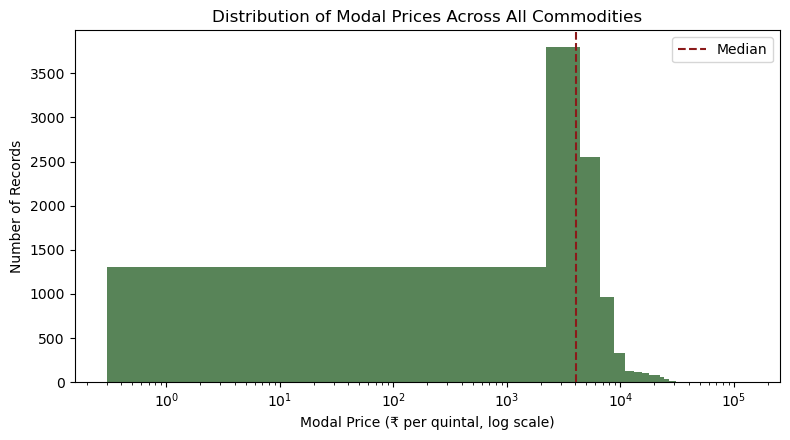

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df["Modal_Price"], bins=60, color="#3b6e3b", alpha=0.85)
ax.set_xscale("log")
ax.set_xlabel("Modal Price (₹ per quintal, log scale)")
ax.set_ylabel("Number of Records")
ax.set_title("Distribution of Modal Prices Across All Commodities")
ax.axvline(df["Modal_Price"].median(), color="#8b1a1a", linestyle="--", label="Median")
ax.legend()
plt.tight_layout()
plt.show()

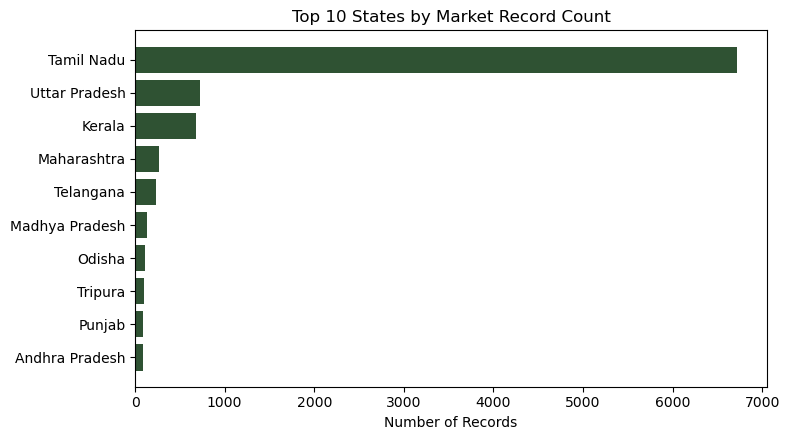

In [17]:
top_states = df["State"].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(top_states.index, top_states.values, color="#2f5233")
ax.set_xlabel("Number of Records")
ax.set_title("Top 10 States by Market Record Count")
plt.tight_layout()
plt.show()

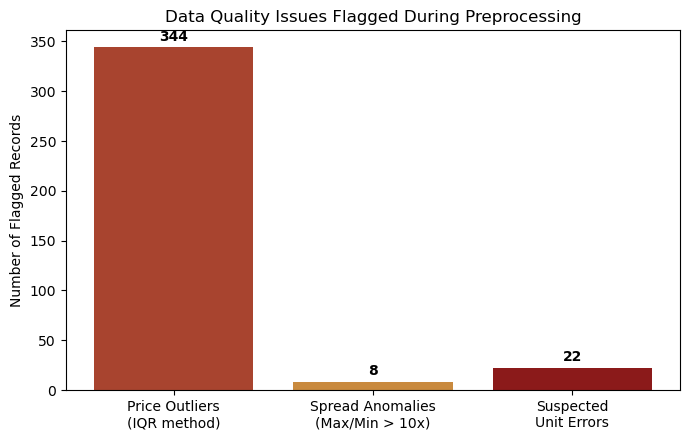

In [18]:
labels = ["Price Outliers\n(IQR method)", "Spread Anomalies\n(Max/Min > 10x)", "Suspected\nUnit Errors"]
values = [
    summary["price_outliers_flagged"],
    summary["spread_anomalies_flagged"],
    summary["suspected_unit_errors_flagged"],
]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(labels, values, color=["#a8442f", "#c98a3e", "#8b1a1a"])
ax.set_ylabel("Number of Flagged Records")
ax.set_title("Data Quality Issues Flagged During Preprocessing")
for i, v in enumerate(values):
    ax.text(i, v + max(values)*0.02, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## Next step

Use the printed numbers from Step 11 and the three charts above directly in your DOC's
Data Quality Assessment, Preprocessing Strategy, and Impact sections — each markdown cell
in this notebook explains the *reasoning* you can reuse as your written justification for
each technique.